<h2 style="text-align:center;font-size:200%;">
    <b>Model Explainability in Industrial Image Detection</b>
</h2>
<h3  style="text-align:center;">Keywords : 
    <span style="border-radius:7px;background-color:limegreen;color:white;padding:7px;">Image Classification</span>
    <span style="border-radius:7px;background-color:limegreen;color:white;padding:7px;">Data Augmentation</span>
    <span style="border-radius:7px;background-color:limegreen;color:white;padding:7px;">CNN</span>
    <span style="border-radius:7px;background-color:limegreen;color:white;padding:7px;">Model Explanation</span>
    <span style="border-radius:7px;background-color:limegreen;color:white;padding:7px;">Error Analysis</span>
</h3>

<hr>

<a id='top'></a>

<h2 style="font-size:150%;"><span id='top'>Table of Contents</span></h2>
<blockquote>
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <ul>
            <li><a href="#Project-Detail">Project Detail</a></li>
            <li><a href="#About-Dataset">About Dataset</a></li>
        </ul>
        <li><a href="#Import-libraries">Import libraries</a></li>
        <li><a href="#Load-the-dataset">Load the dataset</a></li>
        <li><a href="#Pre-Processing">Pre-Processing</a></li>
        <ul>
            <li><a href="#What-is-Data-Augmentation?">What is Data Augmentation?</a></li>
            <li><a href="#Execute-Data-Augmentation">Execute Data Augmentation</a></li>
        </ul>
        <li><a href="#Modeling">Modeling</a></li>
        <ul>
            <li><a href="#Model-Settings">Model Settings</a></li>
            <li><a href="#Build-Model">Build Model</a></li> 
            <li><a href="#Model-Performance">Model Performance</a></li>
            <li><a href="#Predict-on-Some-Images">Predict on Some Images</a></li> 
            <li><a href="#Misclassified-Images">Misclassified Images</a></li> 
            <li><a href="#Explain-Model">Explain Model</a></li> 
            <li><a href="#Explain-Why-Misclassified">Explain Why Misclassified</a></li> 
        </ul>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#References">References</a></li>
    </ol>
</blockquote>


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Overview</div>

## Project Detail

In the manufacturing industry, reducing processing errors in the manufacturing process is important for maximizing profits. In order to reduce processing errors, it is necessary to secure a budget for quality assurance, implement manual inspection work, and review the manufacturing process. Particularly, the inspection process is carried out by many companies, but there are <u>problems such as uneven accuracy denpending on inspection workers and increased labor costs</u>.<br>
In this notebook, we will verify whether the bottleneck of <b>"manual inspection"</b> can be cleared by <u>automating the inspection process by machine learning</u> in the manufacturing process of [casting products](https://en.wikipedia.org/wiki/Casting_%28metalworking%29). [Casting](https://en.wikipedia.org/wiki/Casting) is a technique in which molten metal is poured into a mold and processed into a desired shape.  
According to [this article](https://en.wikipedia.org/wiki/Casting_defect), the following are some of the defects in the casting process.

- blow holes
- pinholes
- burr
- shrinkage defects
- mould material defects
- pouring metal defects
- metallurgical defects

## About Dataset

[This dataset](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product) provides image data of impellers for submersible pumps.<br/><br/>

<table border="0">
     <tr style="background-color: white !important;">
        <td>
            <img src="https://static.turbosquid.com/Preview/2020/06/07__08_34_27/11R131.JPGB3B4468C-B515-4E11-92F7-4CA67966DB2BZoom.jpg" width="300">
            <figcaption style="text-align:center">Submersible Pump</figcaption>
        </td>
        <td>
            <img src="https://5.imimg.com/data5/WI/KC/MY-6121640/submersible-pump-impeller-500x500.jpg" width="300">
            <figcaption style="text-align:center">Impeller</figcaption>
        </td>
    </tr>
 </table><br/>
The image data is labeled with <b>ok(normal)</b> and <b>def(defect/anomaly)</b> in advance. In addition, since it is necessary to illuminate the image in a stable condition when acquiring the image, the data was acquired based on a special lighting setting.


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Import libraries</div>


In [2]:
!pip install numpy pandas matplotlib seaborn holoviews opencv-python tensorflow scikit-learn shap

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/5.9 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.9 MB 6.0 MB/s eta 0:00:01
   ------- -------------------------------- 1.0/5.9 MB 4.9 MB/s eta 0:00:01
   ------- -------------------------------- 1.0/5.9 MB 4.9 MB/s eta 0:00:01
   ---------- ----------------------------- 1.6/5.9 MB 2.1 MB/s eta 0:00:03
   ---------- ----------------------------- 1.6/5.9 MB 2.1 MB/s eta 0:00:03
   -------------- ------------------------- 2.1/5.9 MB 1.7 MB/s eta 0:00:03
   -------------- ------------------------- 2.1/5.9 MB 1.7 MB/s eta 0:00:03
   ----------------- ---------------------- 2.6/5.9 MB 1.6 MB/s eta 0:00:03
   ----------------- ---------------------- 2.6/5.9 MB 1.6 MB/s eta 0:00:03
   --------------------- ------------------ 3.1/5.9 MB 1.5 MB/s eta 0:00:02
   ---------------------- ---------------


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
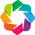

In [3]:
# ===============================
#  Manipulação de sistema e dados
# ===============================
import os
import json
import warnings

# ===============================
#  Manipulação e análise de dados
# ===============================
import numpy as np
import pandas as pd

# ===============================
#  Visualização de dados
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

# ===============================
#  Processamento de imagens
# ===============================
import cv2

# ===============================
#  Machine Learning / Deep Learning
# ===============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend

# ===============================
#  Avaliação de modelos
# ===============================
from sklearn.metrics import confusion_matrix, classification_report

# ===============================
#  Interpretação de modelos (Explainable AI)
# ===============================
import shap

# ===============================
#  Configurações gerais
# ===============================
warnings.filterwarnings('ignore')

# Exibição inline de gráficos no notebook
%matplotlib inline


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Load the dataset</div>


In [4]:
data_dir = "/kaggle/input"

In [5]:
my_data_dir = f'{data_dir}/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/'
train_path = my_data_dir + 'train/'
test_path = my_data_dir + 'test/'

In [9]:
# Define o tamanho da figura para o gráfico (10 de largura x 8 de altura)
plt.figure(figsize=(10, 8))

# Lê uma imagem de uma peça sem defeito (classe 'ok')
ok = plt.imread(train_path + 'ok_front/cast_ok_0_1.jpeg')

# Cria o primeiro subplot (1 linha, 2 colunas, posição 1)
plt.subplot(1, 2, 1)
plt.axis('off')  # Remove os eixos para deixar a imagem mais limpa
plt.title("ok", weight='bold', size=20)  # Define o título do gráfico
plt.imshow(ok, cmap='gray')  # Mostra a imagem em escala de cinza

# Lê uma imagem de uma peça com defeito (classe 'def')
ng = plt.imread(train_path + 'def_front/cast_def_0_1001.jpeg')

# Cria o segundo subplot (1 linha, 2 colunas, posição 2)
plt.subplot(1, 2, 2)
plt.axis('off')  # Remove os eixos novamente
plt.title("def", weight='bold', size=20)  # Título da imagem (defeituosa)
plt.imshow(ng, cmap='gray')  # Exibe a imagem em escala de cinza

# Exibe ambas as imagens lado a lado
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front/cast_ok_0_1.jpeg'

<Figure size 1000x800 with 0 Axes>

<button class="label alert-success" style="border-radius:10px;padding:10px;font-size:18px"><a href="#top" style="color:green;"><b>Table of Contents</b></a></button>


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1; border-radius:10px">Pré-processamento</div>

Ao treinar modelos de classificação de imagens, é importante utilizar técnicas de <b>Aumento de Dados (Data Augmentation)
</b> para construir modelos mais robustos.


## O que é Data Augmentation?

<div class="alert alert-success" role="alert" style="border-radius:10px">
    <p>Ao treinar modelos com dados de imagem **sem aumento de dados**, utilizamos apenas o número original de imagens e criamos mini-lotes diretamente. Já ao aplicar **Data Augmentation (aumento de dados)**, após carregar as imagens, diversas técnicas de transformação são aplicadas para gerar novas variações e criar mini-lotes diferentes a cada época de treinamento.<br/>
    Os principais parâmetros das técnicas de aumento de dados (no Keras ImageDataGenerator ) são: </p>
    <ul>
        <li><b>rotation_range</b> : Rotaciona a imagem (ex.: 50 → rotaciona aleatoriamente entre -50° e 50°)</li>
        <li><b>zoom_range</b> : Aplica zoom in/out na imagem (ex.: 0.5 → aplica zoom aleatoriamente entre 1-0.5 e 1+0.5)</li>
        <li><b>brightness_range</b> : Altera o brilho da imagem (ex.: [0.3, 1.0] → ajusta o brilho aleatoriamente nesse intervalo)</li>
        <li><b>vertical_flip</b> : Espelha a imagem verticalmente (de cabeça para baixo)</li>
        <li><b>horizontal_flip</b> : Espelha a imagem horizontalmente (da esquerda para a direita)</li>
        <li><b>height_shift_range</b> :  Move a imagem para cima ou para baixo (ex.: 0.3 → desloca aleatoriamente entre [-0.3 × altura, 0.3 × altura])</li>
        <li><b>width_shift_range</b> : Move a imagem para a esquerda ou direita (ex.: 0.3 → desloca aleatoriamente entre [-0.3 × largura, 0.3 × largura])</li>
        <li><b>rescale</b> : Normaliza os valores dos pixels multiplicando-os por uma constante (ex.: 1/255 → normaliza os valores RGB entre 0.0 e 1.0)</li>
    </ul>
</div>


In [8]:
# Importa uma imagem de exemplo da pasta de treinamento
img = cv2.imread(train_path + 'ok_front/cast_ok_0_1.jpeg')

# Adiciona uma nova dimensão (necessário para o ImageDataGenerator, que espera lotes de imagens)
img_4d = img[np.newaxis]

# Define o tamanho da figura para exibição das imagens
plt.figure(figsize=(25,10))

# Dicionário de geradores de imagem, cada um aplicando uma técnica diferente de Data Augmentation
generators = {
    "rotation": ImageDataGenerator(rotation_range=180),             # Rotaciona até 180°
    "zoom": ImageDataGenerator(zoom_range=0.7),                     # Aplica zoom in/out
    "brightness": ImageDataGenerator(brightness_range=[0.2,1.0]),   # Altera o brilho
    "height_shift": ImageDataGenerator(height_shift_range=0.7),     # Move verticalmente
    "width_shift": ImageDataGenerator(width_shift_range=0.7)        # Move horizontalmente
}

# Exibe a imagem original
plt.subplot(1, 6, 1)
plt.title("Original", weight='bold', size=15)
plt.imshow(img)
plt.axis('off')

# Contador para organizar os subplots
cnt = 2

# Loop para gerar e exibir uma amostra transformada para cada tipo de augmentação
for param, generator in generators.items():
    image_gen = generator

    # Gera uma nova imagem com a transformação aplicada
    gen = image_gen.flow(img_4d, batch_size=1)
    batches = next(gen)

    # Converte a imagem gerada para uint8 (formato visualizável)
    g_img = batches[0].astype(np.uint8)

    # Mostra a imagem transformada
    plt.subplot(1, 6, cnt)
    plt.title(param, weight='bold', size=15)
    plt.imshow(g_img)
    plt.axis('off')
    cnt += 1

# Exibe todas as imagens lado a lado
plt.show()


TypeError: 'NoneType' object is not subscriptable

## Execute o Aumento de Dados (Data Augmentation)

<div class="alert alert-success" role="alert" style="border-radius:10px"> <p>No Keras, é possível utilizar a classe ImageDataGenerator como fonte de dados durante o treinamento de um modelo. Essa classe cria mini-lotes (mini-batches) aplicando aleatoriamente as transformações definidas nos parâmetros de aumento de dados. <br/><br/> De forma empírica, se os parâmetros forem configurados com valores muito altos ou muito baixos, <u>as imagens serão transformadas de maneira exagerada, dificultando o treinamento do modelo.</u> Além disso, é importante realizar um ajuste fino dos parâmetros de aumento de dados conforme o tipo de imagem ou o objetivo da análise, para garantir um treinamento mais estável e eficiente. <br/><br/> Neste notebook, será executado o aumento de dados com pequenas transformações, baseando-se em exemplos de outros estudos.</p> 
</div>


In [ ]:
# Cria um gerador de dados com aumento (data augmentation)
# - rescale: normaliza os pixels (0–255 → 0–1)
# - zoom_range: aplica zoom aleatório de até ±10%
# - brightness_range: ajusta o brilho das imagens entre 90% e 100% do original
image_gen = ImageDataGenerator(rescale=1/255, zoom_range=0.1, brightness_range=[0.9,1.0])

In [ ]:
# Define o formato esperado das imagens (300x300 pixels e 1 canal, pois são em escala de cinza)
image_shape = (300,300,1)

# Define o tamanho do lote (quantas imagens o modelo verá por vez durante o treinamento)
batch_size = 32

# Cria o conjunto de treinamento aplicando o gerador de dados
train_set = image_gen.flow_from_directory(
    train_path,                     # Caminho para a pasta com imagens de treino
    target_size=image_shape[:2],    # Redimensiona as imagens para 300x300
    color_mode="grayscale",         # Lê as imagens em preto e branco
    classes={'def_front': 0, 'ok_front': 1},  # Define manualmente os rótulos das classes
    batch_size=batch_size,          # Número de imagens por lote
    class_mode='binary',            # Como é uma classificação binária, o rótulo será 0 ou 1
    shuffle=True,                   # Embaralha os dados a cada época para evitar padrões
    seed=0                          # Define uma semente fixa para reprodutibilidade
)

# Cria o conjunto de teste (sem embaralhar)
test_set = image_gen.flow_from_directory(
    test_path,                      # Caminho para a pasta com imagens de teste
    target_size=image_shape[:2],    # Redimensiona para 300x300
    color_mode="grayscale",         # Imagens em escala de cinza
    classes={'def_front': 0, 'ok_front': 1},  # Mapeia classes para valores binários
    batch_size=batch_size,          # Mesmo tamanho de lote do treino
    class_mode='binary',            # Tipo de classificação: binária
    shuffle=False,                  # Não embaralha para manter a ordem nos resultados
    seed=0                          # Mesma semente para consistência
)

In [ ]:
train_set.class_indices

- class 0 : defect
- class 1 : ok


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Modelagem</div>

O modelo será treinado utilizando uma CNN simples (Rede Neural Convolucional), sem o foco em alcançar a maior precisão possível, mas sim em compreender o funcionamento do processo.


## Configurações do Modelo

<div class="alert alert-success" role="alert" style="border-radius:10px">
    Os principais componentes do modelo estão listados abaixo. (<a href="https://www.kaggle.com/ginsaputra/visual-inspection-of-casting-products-using-cnn">Notebook de Referência</a>)</p>
    <ul>
        <li><b>Sequential</b> : Contêiner de modelo sequencial (<a href="https://keras.io/api/models/sequential/">Documentação Oficial</a>) </li>
        <li><b>Conv2D</b> : : Camada convolucional para imagens 2D (<a href="https://keras.io/api/layers/convolution_layers/convolution2d/">Documentação Oficial</a>)  
            <ul>  
                <li><b>filters</b>: Número de filtros  
                    <ul>  
                        <li>Valores como <u>16, 32, 64, 128, 256 e 512</u> são comumente usados. É comum aumentar o número de filtros para tarefas mais complexas e reduzir para tarefas simples.</li>  
                    </ul>  
                </li>  
                <li><b>kernel_size</b>: Tamanho do filtro (largura × altura)  
                    <ul>  
                        <li>Combinações de números ímpares, como <u>3x3, 5x5, 7x7</u>, são mais utilizadas.</li>  
                    </ul>  
                </li>  
                <li><b>strides</b>: Passo da janela usada na convolução</li>  
                <li><b>input_shape</b>: Tamanho das imagens de entrada (largura/altura, canais de cor)  
                    <ul>  
                        <li>Se forem usadas imagens coloridas (RGB), o modelo precisará processar 3 canais, o que aumenta o custo computacional. Imagens em tons de cinza exigem menos processamento.</li>  
                    </ul>  
                </li>  
                <li><b>activation</b>: Função de ativação</li>  
                <li><b>padding</b>: Ajusta o tamanho da saída da camada. Quando definido como ‘same’, adiciona pixels com valor 0 nas bordas para que a entrada e a saída tenham o mesmo tamanho.</li>  
            </ul>  
        </li>
        <li><b>MaxPooling2D</b>: Camada de pooling para imagens 2D (<a href="https://keras.io/api/layers/pooling_layers/max_pooling2d/">Documentação Oficial</a>)  
            <ul>  
                <li><b>pool_size</b>: Define o tamanho da janela e seleciona o valor máximo dentro dela, reduzindo a dimensão da imagem.</li>  
                <li><b>strides</b>: Passo da janela usada no pooling.</li>  
            </ul>  
        </li> 
        <li><b>Flatten</b>: Converte a entrada em um vetor linear (<a href="https://keras.io/api/layers/reshaping_layers/flatten/">Documentação Oficial</a>)</li>  
            <li><b>Dropout</b>: Aplica dropout, definindo aleatoriamente algumas entradas como 0 para evitar overfitting durante o ajuste dos pesos (<a href="https://keras.io/api/layers/regularization_layers/dropout/">Documentação Oficial</a>)  
        <ul>  
            <li><b>rate</b>: Proporção das unidades que serão desativadas (entre 0 e 1).</li>  
        </ul>  
    </li>  
            <li><b>Dense</b>: Camada totalmente conectada (<a href="https://keras.io/api/layers/core_layers/dense/">Documentação Oficial</a>)  
        <ul>  
            <li><b>units</b>: Número de neurônios (dimensões da saída).</li>  
            <li><b>activation</b>: Função de ativação (<u>sigmoid</u> para classificação binária, <u>softmax</u> para múltiplas classes).</li>  
        </ul>  
    </li>  
    </ul>
</div>


In [ ]:
# Limpa quaisquer modelos anteriores carregados na memória do backend do Keras,
# evitando conflitos ou sobreposição de gráficos computacionais.
backend.clear_session()

# Cria um modelo sequencial — ou seja, uma pilha linear de camadas.
model = Sequential()

# Primeira camada convolucional
model.add(Conv2D(
    filters=16,              # número de filtros (detectores de características)
    kernel_size=(7,7),       # tamanho do filtro (janela de convolução)
    strides=2,               # passo da convolução (reduz o tamanho da imagem mais rapidamente)
    input_shape=image_shape, # formato da imagem de entrada (300x300, 1 canal em tons de cinza)
    activation='relu',       # função de ativação ReLU para introduzir não linearidade
    padding='same'           # mantém o mesmo tamanho espacial da entrada (borda é preenchida com zeros)
))

# Camada de pooling (subamostragem)
model.add(MaxPooling2D(
    pool_size=(2, 2),  # tamanho da janela de pooling
    strides=2           # reduz a imagem pela metade
))

# Segunda camada convolucional
model.add(Conv2D(
    filters=32,              # dobra o número de filtros — mais complexidade
    kernel_size=(3,3),       # filtro menor para capturar detalhes
    strides=1,
    activation='relu',
    padding='same'
))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))  # mais uma redução de dimensão

# Terceira camada convolucional
model.add(Conv2D(
    filters=64,              # mais filtros para extrair características mais complexas
    kernel_size=(3,3),
    strides=1,
    activation='relu',
    padding='same'
))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

# Achata o resultado das convoluções em um vetor 1D para entrada nas camadas densas
model.add(Flatten())

# Camada totalmente conectada (fully connected)
model.add(Dense(
    units=224,        # número de neurônios
    activation='relu' # novamente ReLU para aprendizado não linear
))

# Dropout — ajuda a evitar overfitting desligando aleatoriamente 20% dos neurônios
model.add(Dropout(rate=0.2))

# Camada de saída
model.add(Dense(
    units=1,           # saída binária (defeito = 0, ok = 1)
    activation='sigmoid'  # gera uma probabilidade entre 0 e 1
))

# Compilação do modelo: define como ele será treinado
model.compile(
    loss='binary_crossentropy',  # função de perda apropriada para classificação binária
    optimizer='adam',            # otimizador adaptativo eficiente
    metrics=['accuracy']         # métrica a ser monitorada
)

# Mostra um resumo da arquitetura do modelo (camadas, parâmetros, saídas, etc.)
model.summary()


A figura a seguir apresenta a arquitetura da rede neural construída.

In [ ]:
plot_model(model, show_shapes=True, expand_nested=True, dpi=60)

## Construção do Modelo
<div class="alert alert-success" role="alert" style="border-radius:10px"> Configurações de construção: <ul> <li><b>EarlyStopping</b> : Condições para interromper o treinamento antecipadamente (<a href='https://keras.io/api/callbacks/early_stopping/'>Manual Oficial</a>)</li> <ul> <li>Exemplo: a perda de validação (validation loss) não melhora continuamente por 2 épocas.</li> </ul> <li><b>ModelCheckpoint</b> : Configurações para salvar o modelo a cada época (<a href='https://keras.io/api/callbacks/model_checkpoint/'>Manual Oficial</a>)</li> </ul> </div>

In [ ]:
# Caminho e nome do arquivo onde o melhor modelo será salvo
model_save_path = 'casting_product_detection.hdf5'

# Cria o callback EarlyStopping
# -> monitor='val_loss': observa a perda na validação
# -> patience=2: interrompe o treinamento se a perda de validação não melhorar por 2 épocas consecutivas
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# Cria o callback ModelCheckpoint
# -> filepath=model_save_path: define onde salvar o modelo
# -> verbose=1: exibe mensagens no console quando o modelo é salvo
# -> save_best_only=True: salva apenas o modelo com a melhor métrica (menor val_loss)
# -> monitor='val_loss': usa a perda na validação como critério de comparação
checkpoint = ModelCheckpoint(filepath=model_save_path, verbose=1, save_best_only=True, monitor='val_loss')


In [ ]:
# Define o número máximo de épocas (iterações completas sobre o conjunto de treinamento)
n_epochs = 20

# Treina o modelo com o conjunto de dados e os callbacks configurados
# fit() é usado quando os dados são gerados em lotes (batches) por um gerador como o ImageDataGenerator
results = model.fit(
    train_set,             # conjunto de treinamento com aumento de dados (data augmentation)
    epochs=n_epochs,       # número máximo de épocas de treinamento
    validation_data=test_set,  # conjunto de validação para avaliar o desempenho a cada época
    callbacks=[early_stop, checkpoint]  # callbacks para parada antecipada e salvamento do melhor modelo
)


In [ ]:
# Salva o histórico de treinamento do modelo em um arquivo JSON
# (útil para visualizar ou analisar posteriormente as métricas de treino e validação)

# Converte o histórico retornado pelo treinamento (results.history)
# em um dicionário de listas de números float
# results.history contém valores como loss, accuracy, val_loss, val_accuracy
model_history = { 
    i: list(map(lambda x: float(x), j))   # garante que todos os valores sejam floats (não objetos numpy)
    for i, j in results.history.items()   # percorre cada métrica e seus valores
}

# Abre (ou cria) um arquivo JSON chamado 'model_history.json' para escrita
with open('model_history.json', 'w') as f:
    # Salva o dicionário no arquivo com indentação de 4 espaços para melhor legibilidade
    json.dump(model_history, f, indent=4)


Reutilizando um modelo treinado e o histórico de treinamento

In [ ]:
#model = load_model("/kaggle/input/casting-product-detectionhdf5/casting_product_detection.hdf5")
#model_history = json.load(open('/kaggle/input/model-historyjson/model_history.json', 'r'))

## Desempenho do Modelo

In [ ]:
# Cria um DataFrame do pandas a partir do dicionário 'model_history'
# Esse dicionário contém as métricas registradas durante o treinamento (ex: loss, accuracy, val_loss, val_accuracy)
losses = pd.DataFrame(model_history)

# Ajusta o índice do DataFrame para começar em 1 (representando as épocas de treinamento)
# Por padrão, o índice começa em 0, então aqui somamos +1
losses.index = map(lambda x: x + 1, losses.index)

# Exibe as 3 primeiras linhas do DataFrame para verificar o conteúdo
losses.head(3)


Como a perda (loss) durante o treinamento e a validação diminui de forma constante a cada época, e a acurácia (accuracy) durante o treinamento e a validação aumenta de maneira contínua, pode-se dizer que o treinamento foi, de modo geral, bem-sucedido.

In [ ]:
# Cria curvas interativas com o Holoviews para visualizar as métricas do modelo
# São plotadas 4 curvas: perda (loss) e acurácia (accuracy) — tanto para treino quanto para validação

g = (
    hv.Curve(losses.loss, label='Training Loss') *             # Curva da perda no treinamento
    hv.Curve(losses.val_loss, label='Validation Loss') *       # Curva da perda na validação
    hv.Curve(losses.accuracy, label='Training Accuracy') *     # Curva da acurácia no treinamento
    hv.Curve(losses.val_accuracy, label='Validation Accuracy') # Curva da acurácia na validação
)

# Define as opções de exibição do gráfico
g.opts(
    opts.Curve(
        xlabel="Épocas",                        # Rótulo do eixo X
        ylabel="Perda / Acurácia",              # Rótulo do eixo Y
        width=700,                              # Largura do gráfico
        height=400,                             # Altura do gráfico
        tools=['hover'],                        # Mostra valores ao passar o mouse
        show_grid=True,                         # Exibe grade de fundo
        title='Avaliação do Modelo'             # Título do gráfico
    )
).opts(
    legend_position='bottom'                    # Exibe a legenda na parte inferior
)


<div class="alert alert-success" role="alert" style="border-radius:10px"> <p>Avalie o modelo com o conjunto de teste.<br> De acordo com a matriz de confusão, das 715 imagens, 1 foi classificada incorretamente como defeituosa (<b>Falso Positivo</b>), e 2 foram classificadas incorretamente como normais (<b>Falsos Negativos</b>).<br> No problema de inspeção de imagens de produtos industriais, é possível que ocorram os seguintes impactos devido à classificação incorreta:</p> <ul> <li><b>Falso Negativo</b> : Como se trata de um caso de <u>“não detecção”</u>, ou seja, o modelo não consegue identificar uma imagem com defeito como “defeituosa”, existe o risco de que isso afete negativamente as etapas subsequentes da produção ou resulte em defeitos no produto final.</li> <li><b>Falso Positivo</b> : Como se trata de um caso de <u>“detecção excessiva”</u>, ou seja, o modelo classifica incorretamente uma imagem normal como “defeituosa”, existe o risco de aumento desnecessário no tempo de parada da linha de produção ou de custos adicionais com retrabalho.</li> </ul> <p>Decidir se deve-se priorizar a redução de <b>Falsos Positivos</b> ou <b>Falsos Negativos</b> (dependendo dos requisitos do negócio) determina qual métrica deve ser usada na avaliação do modelo: <b>Precisão (Precision)</b> ou <b>Revocação (Recall)</b>. Se quiser considerar ambas, use o <b>F1-Score</b>, que é a média harmônica entre Precisão e Revocação.</p> </div>

In [ ]:
# Usa o modelo treinado para prever a probabilidade de cada imagem do conjunto de teste
# O método predict_generator gera as predições em lotes (batchs) de forma eficiente
pred_probability = model.predict(test_set)

# Converte as probabilidades em classes (0 ou 1)
# Se a probabilidade for maior que 0.5, a imagem é classificada como "Defect" (True)
# Caso contrário, é "OK" (False)
predictions = pred_probability > 0.5

# Cria uma nova figura para o gráfico, com tamanho 10x6 polegadas
plt.figure(figsize=(10,6))

# Define o título da figura
plt.title("Confusion Matrix", size=20, weight='bold')

# Cria a matriz de confusão usando Seaborn (sns.heatmap)
# A função confusion_matrix compara as classes reais (test_set.classes)
# com as previsões feitas pelo modelo (predictions)
sns.heatmap(
    confusion_matrix(test_set.classes, predictions),  # dados da matriz
    annot=True,                                       # exibe os números dentro das células
    annot_kws={'size':14, 'weight':'bold'},           # estilo dos números (tamanho e negrito)
    fmt='d',                                          # formata os valores como inteiros
    xticklabels=['Defect', 'OK'],                     # rótulos do eixo X (valores previstos)
    yticklabels=['Defect', 'OK']                      # rótulos do eixo Y (valores reais)
)

# Ajusta o tamanho da fonte dos rótulos dos eixos
plt.tick_params(axis='both', labelsize=14)

# Define o rótulo do eixo Y (valores reais)
plt.ylabel('Actual', size=14, weight='bold')

# Define o rótulo do eixo X (valores previstos)
plt.xlabel('Predicted', size=14, weight='bold')

# Exibe o gráfico na tela
plt.show()


In [ ]:
print(classification_report(test_set.classes, predictions, digits=3))

## Prever em Algumas Imagens

Selecione algumas imagens e aplique o modelo para fazer previsões.

In [ ]:
# Lista de imagens de teste para prever (5 normais e 5 com defeito)
test_cases = [
    'ok_front/cast_ok_0_10.jpeg', 'ok_front/cast_ok_0_1026.jpeg', 'ok_front/cast_ok_0_1031.jpeg', 
    'ok_front/cast_ok_0_1121.jpeg', 'ok_front/cast_ok_0_1144.jpeg',
    'def_front/cast_def_0_1059.jpeg', 'def_front/cast_def_0_108.jpeg', 
    'def_front/cast_def_0_1153.jpeg', 'def_front/cast_def_0_1238.jpeg', 'def_front/cast_def_0_1269.jpeg'
]

# Cria uma figura com 2 linhas e 5 colunas (para mostrar 10 imagens)
plt.figure(figsize=(20,8))

# Loop para percorrer todas as imagens selecionadas
for i in range(len(test_cases)):
    # Lê a imagem em tons de cinza
    img_pred = cv2.imread(test_path + test_cases[i], cv2.IMREAD_GRAYSCALE)
    
    # Normaliza os valores de pixel (de 0–255 para 0–1)
    img_pred = img_pred / 255 
    
    # Faz a previsão com o modelo treinado
    prediction = model.predict(img_pred.reshape(1, *image_shape))
    
    # Lê novamente a imagem em cores (para mostrar com texto colorido)
    img = cv2.imread(test_path + test_cases[i])
    
    # Extrai o rótulo real ("ok" ou "def") do nome do arquivo
    label = test_cases[i].split("_")[0]
    
    # Define a posição da imagem no grid
    plt.subplot(2, 5, i+1)
    plt.title(f"{test_cases[i].split('/')[1]}\n Actual Label : {label}", weight='bold', size=12)
    
    # Se a previsão for menor que 0.5 → classe "defeito"
    if (prediction < 0.5):
        predicted_label = "def"
        prob = (1 - prediction.sum()) * 100
    # Caso contrário → classe "OK"
    else:
        predicted_label = "ok"
        prob = prediction.sum() * 100
        
    # Adiciona o texto com a previsão sobre a imagem
    cv2.putText(img=img, text=f"Predicted Label : {predicted_label}", 
                org=(10, 30), fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
                fontScale=0.8, color=(255, 0, 255), thickness=2)
    
    # Adiciona o texto com a probabilidade da previsão
    cv2.putText(img=img, text=f"Probability : {'{:.3f}'.format(prob)}%", 
                org=(10, 280), fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
                fontScale=0.7, color=(0, 255, 0), thickness=2)
    
    # Exibe a imagem no gráfico
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Mostra todas as previsões na tela
plt.show()


## Imagens Classificadas Incorretamente

Vamos observar as imagens classificadas incorretamente no conjunto de teste.
Não é claro, a olho nu, por que elas foram classificadas de forma errada.


In [ ]:
# Cria uma lista com os caminhos das imagens de teste das pastas "ok_front" e "def_front"
test_cases = ['ok_front/' + i for i in os.listdir(f'{data_dir}/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front')]
test_cases.extend(['def_front/' + i for i in os.listdir(f'{data_dir}/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front')])

plt.figure(figsize=(20,8))
cnt = 0  # contador para limitar o número de imagens exibidas
misclassified = []  # lista para armazenar as imagens classificadas incorretamente

# Percorre todas as imagens de teste
for i in range(len(test_cases)):
    if cnt == 10:
        break  # exibe no máximo 10 imagens

    # Lê a imagem em escala de cinza
    img_pred = cv2.imread(test_path + test_cases[i], cv2.IMREAD_GRAYSCALE)
    try:
        img_pred = img_pred / 255  # normaliza os valores de pixel entre 0 e 1
    except:
        continue  # se der erro na leitura, pula para a próxima imagem

    # Faz a predição com o modelo
    prediction = model.predict(img_pred.reshape(1, *image_shape))
    
    # Lê novamente a imagem (agora em RGB) para exibição
    img = cv2.imread(test_path + test_cases[i])
    label = test_cases[i].split("_")[0]  # extrai o rótulo real (ok ou def)

    # Classe prevista: defeituosa
    if (prediction < 0.5):
        predicted_label = "def"
        prob = (1 - prediction.sum()) * 100
    # Classe prevista: normal (OK)
    else:
        predicted_label = "ok"
        prob = prediction.sum() * 100

    # Seleciona casos em que o rótulo real é diferente da predição
    if label != predicted_label:
        misclassified.append(test_cases[i])  # salva o nome do arquivo
        plt.subplot(2, 5, cnt + 1)
        plt.title(f"{test_cases[i].split('/')[1]}\n Rótulo Real : {label}", weight='bold', size=12)
        
        # Adiciona texto na imagem com o resultado da predição e probabilidade
        cv2.putText(img=img, text=f"Rótulo Previsto : {predicted_label}", org=(10, 30),
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.8, color=(255, 0, 255), thickness=2)
        cv2.putText(img=img, text=f"Probabilidade : {'{:.3f}'.format(prob)}%", org=(10, 280),
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.7, color=(0, 255, 0), thickness=2)

        # Exibe a imagem
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        cnt += 1  # incrementa o contador
    else:
        continue  # se a imagem foi classificada corretamente, ignora

plt.show()  # exibe as imagens classificadas incorretamente


## Explicando o modelo
<div class="alert alert-success" role="alert" style="border-radius:10px">
Realizamos a interpretação do modelo utilizando a biblioteca <a href='https://github.com/slundberg/shap'>SHAP</a>. Vamos usar algumas das imagens que foram classificadas como <b>defeituosas</b> para entender quais partes das imagens foram consideradas características importantes pelo modelo. <br>
Ao observar a <b>parte azul</b> dos resultados do SHAP, podemos considerar que o modelo identifica <u>riscos/buracos na superfície dos produtos e irregularidades ao redor das peças</u> como os principais indicadores de produtos defeituosos.
</div>

In [ ]:
# Cria uma lista com o caminho de todas as imagens de treinamento classificadas como 'ok'
train_cases = ['ok_front/' + i for i in os.listdir(f'{data_dir}/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front')]

# Adiciona também as imagens classificadas como 'defeituosas'
train_cases.extend(['def_front/' + i for i in os.listdir(f'{data_dir}/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/def_front')])

# Seleciona aleatoriamente 3000 imagens do conjunto de treinamento
# Cada imagem é lida em tons de cinza (cv2.IMREAD_GRAYSCALE), redimensionada para o formato esperado pelo modelo
# e normalizada (dividida por 255 para que os valores de pixels fiquem entre 0 e 1)
train_sample = [
    cv2.imread(train_path + i, cv2.IMREAD_GRAYSCALE).reshape(1, *image_shape) / 255
    for i in np.random.choice(train_cases, 3000, replace=False)
]

# Inicializa o interpretador SHAP para redes neurais profundas
# Ele utiliza o modelo treinado e uma imagem de referência (a primeira do conjunto de amostras)
explainer = shap.DeepExplainer(model, train_sample[0])


In [ ]:
# Lista de imagens de teste que foram classificadas como "defeituosas" (def_front)
test_cases = [
    'def_front/cast_def_0_1059.jpeg',
    'def_front/cast_def_0_108.jpeg',
    'def_front/cast_def_0_1153.jpeg',
    'def_front/cast_def_0_1238.jpeg',
    'def_front/cast_def_0_1269.jpeg'
]

# Loop que percorre cada imagem da lista de teste
for i in test_cases:
    # Lê a imagem em tons de cinza e redimensiona para o formato esperado pelo modelo
    # Também faz a normalização dos pixels (0 a 1)
    img = cv2.imread(test_path + i, cv2.IMREAD_GRAYSCALE).reshape(1, *image_shape) / 255

    # Calcula os valores SHAP para a imagem
    # Esses valores indicam o quanto cada pixel contribuiu para a decisão do modelo
    shap_values = explainer.shap_values(img)

    # Plota o mapa de calor gerado pelo SHAP sobre a imagem original
    # As áreas azuis/vermelhas mostram onde o modelo "prestou atenção"
    shap.image_plot(shap_values, img, show=False) 

    # Define o título da imagem exibida, mostrando o nome do arquivo e o rótulo real
    plt.title(f"{i.split('/')[1]}\n Actual Label : {i.split('_')[0]}", weight='bold', size=12)

    # Remove os eixos para deixar a visualização mais limpa
    plt.axis('off')

#


## Explicar por que foram classificadas incorretamente

Considere por que as imagens classificadas incorretamente foram mal classificadas usando o SHAP, como feito acima.
Acredita-se que as sombras, riscos e buracos nas imagens foram ignorados e, por isso, o modelo as julgou como normais.

In [ ]:
# Para cada imagem incorretamente classificada (armazenada na lista 'misclassified')
for i in misclassified:
    # Lê a imagem em tons de cinza e redimensiona para o formato de entrada do modelo
    # Também normaliza os valores de pixel (dividindo por 255)
    img = cv2.imread(test_path + i, cv2.IMREAD_GRAYSCALE).reshape(1, *image_shape) / 255

    # Calcula os valores SHAP (importância dos pixels) para a imagem
    shap_values = explainer.shap_values(img)

    # Gera o gráfico SHAP mostrando as regiões da imagem que mais influenciaram a predição do modelo
    shap.image_plot(shap_values, img, show=False) 

    # Adiciona um título indicando o nome da imagem e o rótulo real
    plt.title(f"{i.split('/')[1]}\n Actual Label : {i.split('_')[0]}", weight='bold', size=12)

    # Remove os eixos do gráfico para deixar a visualização mais limpa
    plt.axis('off')

# Exibe todos os gráficos gerados
plt.show()


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Conclusão</div>

<div class="alert alert-success" role="alert" style="border-radius:10px">
    <ul>
        <li>O processo de <b>aumento de dados (data augmentation)</b> pode ser facilmente incorporado ao treinamento usando o <b>ImageDataGenerator</b>.</li>
        <li>No processo de aumento de dados, devemos evitar transformações excessivas e realizar ajustes sutis dependendo do conjunto de dados.</li>
        <li>De acordo com o resultado da interpretação do modelo, verificou-se que <b>os arranhões/buracos na superfície dos produtos e as irregularidades ao redor deles</b> são considerados as principais características dos produtos defeituosos.</li>
        <li>Como conseguimos construir um modelo com precisão relativamente alta, considera-se possível incorporá-lo à câmera da linha de inspeção e prosseguir com a automação do processo de inspeção.
            <ul>
                <li>No entanto, levando em conta os danos causados por detecções incorretas, não há total confiabilidade até que o modelo seja usado em automação completa (também existem dificuldades relacionadas à aquisição de imagens, como iluminação). Portanto, deve-se introduzi-lo como uma ferramenta de apoio aos inspetores ou como um método de economia de trabalho.</li>
                <li>Além disso, há uma ideia de melhorar o modelo e o sistema de detecção de produtos defeituosos de forma <b><a href="https://ieeexplore.ieee.org/document/9493179">Human-in-the-Loop</a></b> (com a intervenção humana).</li>
            </ul>
        </li>
    </ul>
</div>


# <div style="text-align: left; background-color: mediumseagreen; color: white; padding: 10px; line-height:1;border-radius:10px">Referencias</div>

- Keras Official Manual
  - https://keras.io/ja/
- Image Data Pre-Processing Techniques
  - https://pynote.hatenablog.com/entry/keras-image-data-generator
- Keras ImageDataGenerator
  - https://keras.io/ja/preprocessing/image/
- OpenCV puttext
  - http://opencv.jp/opencv-2svn/cpp/drawing_functions.html#cv-puttext
- CNN Basic Explanation
  - https://products.sint.co.jp/aisia/blog/vol1-16
- CNN Implementations using Keras
  - https://qiita.com/kenichiro-yamato/items/60affeb7ca9f67c87a17
  - https://child-programmer.com/ai/keras/conv2d/
  - https://child-programmer.com/ai/keras/maxpooling2d/
- SHAP Deep Explainer
  - https://shap-lrjball.readthedocs.io/en/latest/generated/shap.DeepExplainer.html
- SHAP Image Plot
  - https://shap-lrjball.readthedocs.io/en/latest/generated/shap.image_plot.html
- Referenced Notebooks
  - CNN Implementation
    - https://www.kaggle.com/ravirajsinh45/simple-model-for-casting-product-classification
    - https://www.kaggle.com/ginsaputra/visual-inspection-of-casting-products-using-cnn
    - https://www.kaggle.com/tomythoven/casting-inspection-with-data-augmentation-cnn
  - Feature Map
    - https://www.kaggle.com/vannak/magical-localized-fault-detection
- MISC
  - https://codepen.io/ikapper/pen/EqaVjP
